# Evaluación Científica Integral (Fase 4)

Este notebook genera la batería completa de métricas y visualizaciones necesarias para un artículo académico (Paper o Tesis). Compara 3 modelos (Master Transformer, LSTM y Transformer Ablación) y genera:
1. Líneas temporales reales vs predichas.
2. Leaderboard de métricas (MAE, MSE, RMSE, MAPE, R2).
3. Gráficos de barras comparativos.
4. Dispersión (Scatter Plot) de precisión.
5. Distribución de los errores.
6. Mapa de Calor de Atención Cruzada (Interpretabilidad).

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from networks import StockDataset, MasterStockTransformer, LSTMModel

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

### 1. Preparación de Entorno y Datos

In [2]:
df = pd.read_csv('processed_market_data.csv', index_col=0, parse_dates=True)

target_idx = df.columns.get_loc('JPM_Log_Ret')
ma5_idx = df.columns.get_loc('JPM_Target_MA5')
close_idx = df.columns.get_loc('JPM_Close')

ctx_full = [i for i in range(len(df.columns)) if i not in [target_idx, ma5_idx, close_idx]]
jpm_cols = [c for c in df.columns if ('JPM' in c or 'Sin' in c or 'Cos' in c) and c not in ['JPM_Log_Ret', 'JPM_Target_MA5', 'JPM_Close']]
ctx_abl = [df.columns.get_loc(c) for c in jpm_cols]

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size+val_size:] 

seq_length = 20 
test_dates = test_df.index[seq_length:] 

scaler = StandardScaler()
scaler.fit(train_df)
test_scaled = scaler.transform(test_df)

test_loader_full = DataLoader(StockDataset(test_scaled, target_idx, ctx_full, seq_length), batch_size=1, shuffle=False)
test_loader_abl = DataLoader(StockDataset(test_scaled, target_idx, ctx_abl, seq_length), batch_size=1, shuffle=False)

### 2. Inferencia y Extracción de Pesos de Atención

In [3]:
def get_predictions(model, loader, model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    preds, attentions = [], []
    with torch.no_grad():
        for x_tgt, x_ctx, _ in loader:
            x_tgt, x_ctx = x_tgt.to(device), x_ctx.to(device)
            pred, attn = model(x_tgt, x_ctx)
            preds.append(pred.cpu().item())
            if attn is not None:
                attentions.append(attn.cpu().numpy())
                
    dummy = np.zeros((len(preds), len(df.columns)))
    dummy[:, target_idx] = preds
    return scaler.inverse_transform(dummy)[:, target_idx], attentions

def get_true_returns():
    targets = [y_true.item() for _, _, y_true in test_loader_full]
    dummy = np.zeros((len(targets), len(df.columns)))
    dummy[:, target_idx] = targets
    return scaler.inverse_transform(dummy)[:, target_idx]

y_true_ret = get_true_returns()

# ¡ACTUALIZADO A LOS HIPERPARÁMETROS ÓPTIMOS DEL TUNING!
OPTIMAL_LAYERS = 1
OPTIMAL_DROPOUT = 0.1

model_master = MasterStockTransformer(target_features=1, context_features=len(ctx_full), 
                                      d_model=128, nhead=4, num_layers=OPTIMAL_LAYERS, dropout=OPTIMAL_DROPOUT).to(device)
pred_ret_master, attn_master = get_predictions(model_master, test_loader_full, 'master_model_tuned.pth')

model_lstm = LSTMModel(target_features=1, context_features=len(ctx_full), 
                       hidden_size=128, num_layers=OPTIMAL_LAYERS, dropout=0.0).to(device)
pred_ret_lstm, _ = get_predictions(model_lstm, test_loader_full, 'baseline_lstm.pth')

model_abl = MasterStockTransformer(target_features=1, context_features=len(ctx_abl), 
                                   d_model=128, nhead=4, num_layers=OPTIMAL_LAYERS, dropout=OPTIMAL_DROPOUT).to(device)
pred_ret_abl, _ = get_predictions(model_abl, test_loader_abl, 'master_model_ablation.pth')

### 3. Reconstrucción de Precios

In [4]:
true_price = test_df['JPM_Close'].iloc[seq_length:].values
prev_price = test_df['JPM_Close'].iloc[seq_length-1:-1].values

results_df = pd.DataFrame({
    'Real': true_price,
    'MASTER': prev_price * np.exp(pred_ret_master),
    'LSTM': prev_price * np.exp(pred_ret_lstm),
    'Ablacion': prev_price * np.exp(pred_ret_abl)
}, index=test_dates[:len(true_price)])

--- 
### GRÁFICO 1: Tabla Completa de Métricas (Leaderboard)

In [5]:
def calculate_metrics(y_true, y_pred):
    return {
        'MAE (Error Absoluto $)': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE ($)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R2 Score': r2_score(y_true, y_pred)
    }

leaderboard = pd.DataFrame([
    calculate_metrics(results_df['Real'], results_df['MASTER']),
    calculate_metrics(results_df['Real'], results_df['LSTM']),
    calculate_metrics(results_df['Real'], results_df['Ablacion'])
], index=['Transformer MASTER (Full)', 'Baseline LSTM', 'Transformer Ablación (Solo JPM)'])

display(leaderboard.round(4))

,MAE (Error Absoluto $),MSE,RMSE ($),MAPE (%),R2 Score
Transformer MASTER (Full),2.8100,16.1506,4.0188,1.1150,0.9930
Baseline LSTM,3.2124,19.3703,4.4012,1.2844,0.9916
Transformer Ablación (Solo JPM),2.8981,16.8655,4.1068,1.1490,0.9927


### GRÁFICO 2: Comparativa Visual de Precios Reconstruidos

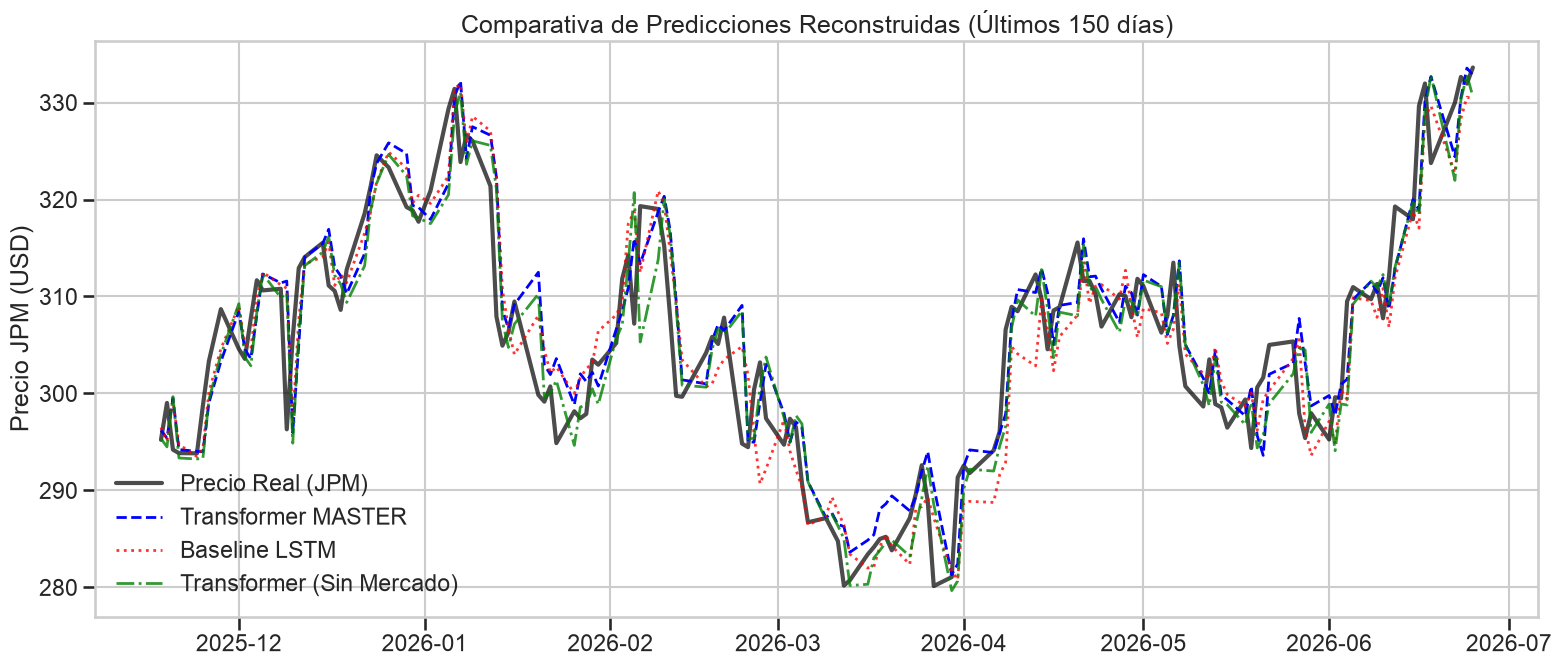

In [6]:
plt.figure(figsize=(16, 7))
zoom = results_df.iloc[-150:] # Últimos 150 días para ver detalles

plt.plot(zoom.index, zoom['Real'], label='Precio Real (JPM)', color='black', linewidth=3, alpha=0.7)
plt.plot(zoom.index, zoom['MASTER'], label='Transformer MASTER', color='blue', linestyle='--', linewidth=2)
plt.plot(zoom.index, zoom['LSTM'], label='Baseline LSTM', color='red', linestyle=':', linewidth=2, alpha=0.8)
plt.plot(zoom.index, zoom['Ablacion'], label='Transformer (Sin Mercado)', color='green', linestyle='-.', linewidth=2, alpha=0.8)

plt.title('Comparativa de Predicciones Reconstruidas (Últimos 150 días)')
plt.ylabel('Precio JPM (USD)')
plt.legend()
plt.tight_layout()
import os
os.makedirs('img', exist_ok=True)
plt.savefig('img/graph1.png', bbox_inches='tight', dpi=300)
plt.show()

### GRÁFICO 3: Gráfico de Barras (RMSE y MAE)

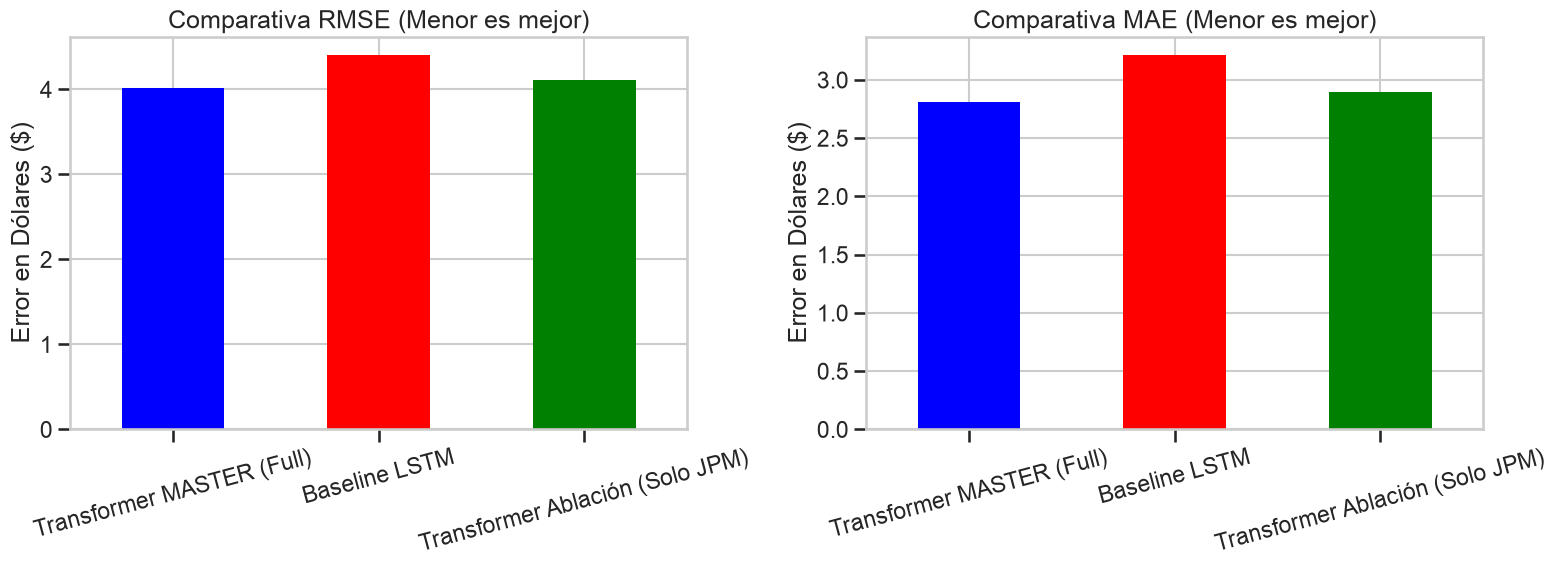

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

leaderboard['RMSE ($)'].plot(kind='bar', color=['blue', 'red', 'green'], ax=ax[0])
ax[0].set_title('Comparativa RMSE (Menor es mejor)')
ax[0].set_ylabel('Error en Dólares ($)')
ax[0].tick_params(axis='x', rotation=15)

leaderboard['MAE (Error Absoluto $)'].plot(kind='bar', color=['blue', 'red', 'green'], ax=ax[1])
ax[1].set_title('Comparativa MAE (Menor es mejor)')
ax[1].set_ylabel('Error en Dólares ($)')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
import os
os.makedirs('img', exist_ok=True)
plt.savefig('img/graph2.png', bbox_inches='tight', dpi=300)
plt.show()

### GRÁFICO 4: Dispersión de Precisión (Scatter Plot $y=x$)

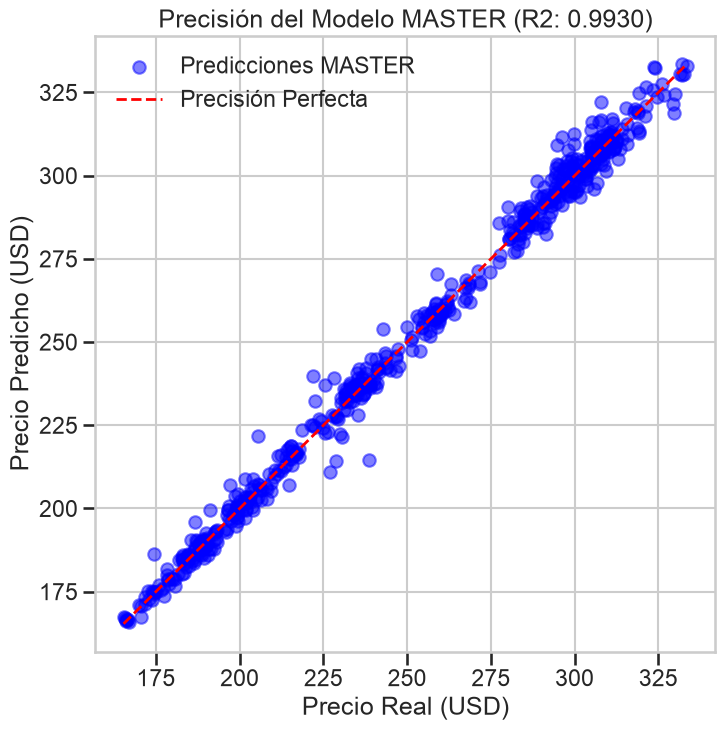

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(results_df['Real'], results_df['MASTER'], alpha=0.5, color='blue', label='Predicciones MASTER')

# Línea ideal (y=x)
min_val = min(results_df['Real'].min(), results_df['MASTER'].min())
max_val = max(results_df['Real'].max(), results_df['MASTER'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Precisión Perfecta')

plt.title(f"Precisión del Modelo MASTER (R2: {leaderboard.loc['Transformer MASTER (Full)', 'R2 Score']:.4f})")
plt.xlabel("Precio Real (USD)")
plt.ylabel("Precio Predicho (USD)")
plt.legend()
import os
os.makedirs('img', exist_ok=True)
plt.savefig('img/graph3.png', bbox_inches='tight', dpi=300)
plt.show()

### GRÁFICO 5: Distribución de Errores (Histograma)
Verifica si los errores del modelo se distribuyen normalmente (Ruido Blanco).

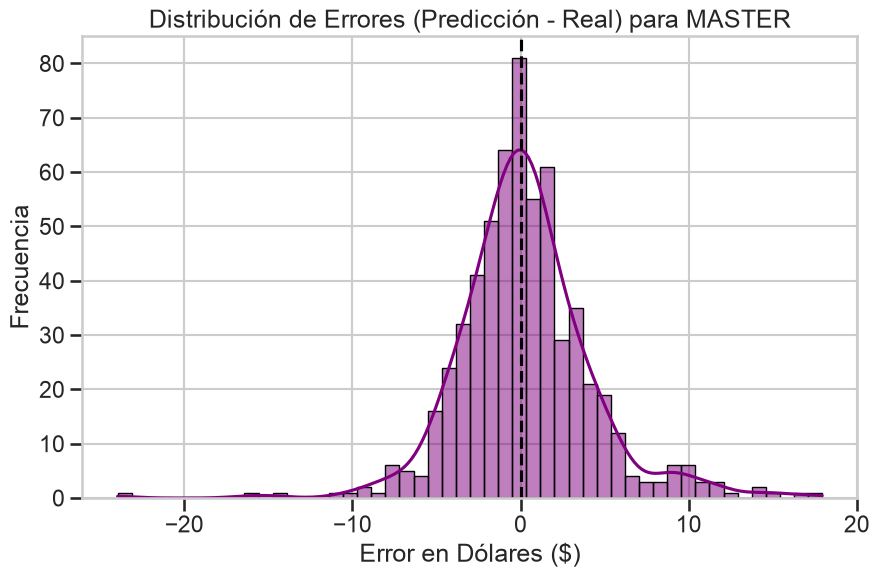

In [9]:
errores_master = results_df['MASTER'] - results_df['Real']

plt.figure(figsize=(10, 6))
sns.histplot(errores_master, kde=True, bins=50, color='purple')
plt.title("Distribución de Errores (Predicción - Real) para MASTER")
plt.xlabel("Error en Dólares ($)")
plt.ylabel("Frecuencia")
plt.axvline(x=0, color='black', linestyle='--')
import os
os.makedirs('img', exist_ok=True)
plt.savefig('img/graph4.png', bbox_inches='tight', dpi=300)
plt.show()

### GRÁFICO 6: La Joya de la Corona - Mapa de Atención Cruzada
Este gráfico comprueba nuestra hipótesis principal: Extrae matemáticamente a qué días del mercado prestó atención el modelo para predecir a JPM.

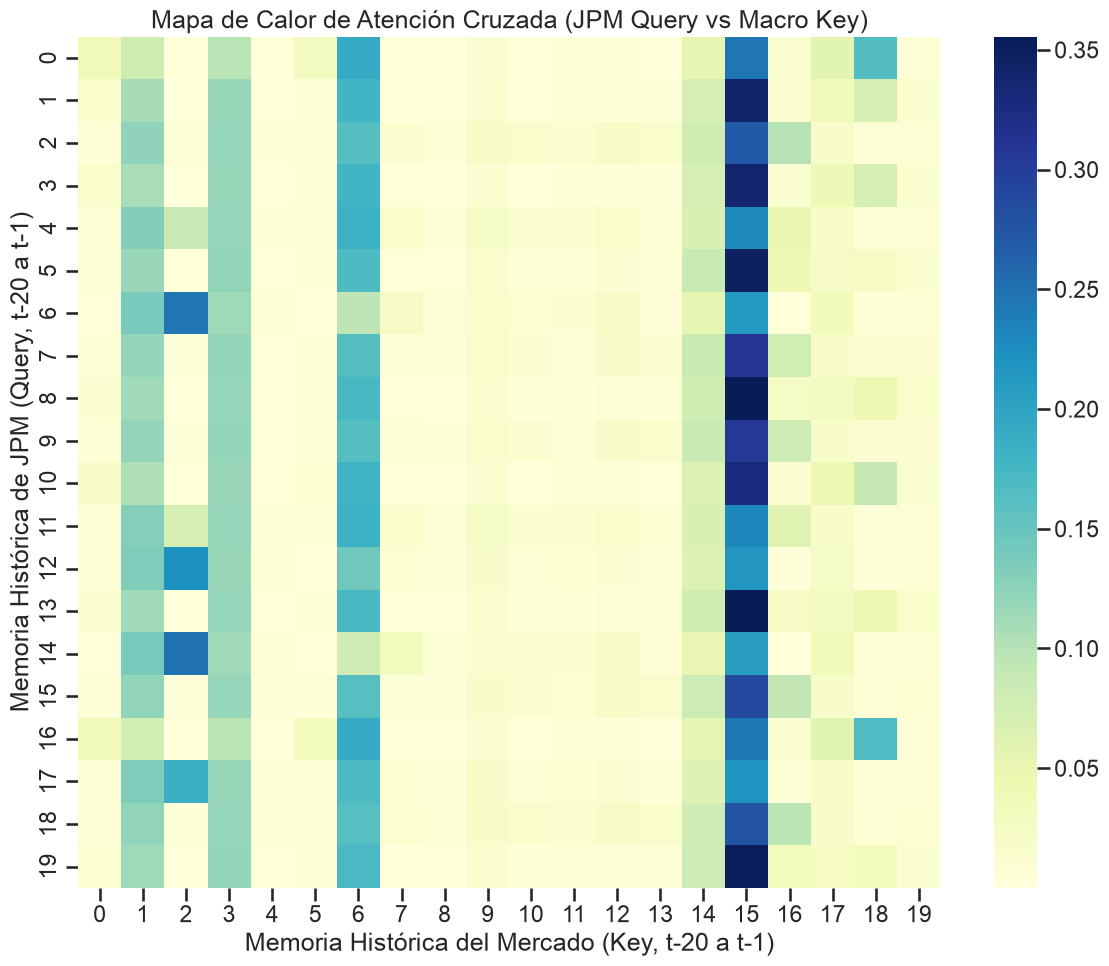

In [10]:
# Obtenemos la matriz de atención del último día evaluado
# shape original del batch: (Batch=1, Seq=20, Seq=20). Tomamos el índice 0 para quitar la dimensión del batch.
last_attn_matrix = attn_master[-1][0] 

plt.figure(figsize=(12, 10))
sns.heatmap(last_attn_matrix, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Mapa de Calor de Atención Cruzada (JPM Query vs Macro Key)")
plt.xlabel("Memoria Histórica del Mercado (Key, t-20 a t-1)")
plt.ylabel("Memoria Histórica de JPM (Query, t-20 a t-1)")
plt.tight_layout()
import os
os.makedirs('img', exist_ok=True)
plt.savefig('img/graph5.png', bbox_inches='tight', dpi=300)
plt.show()